# 01 - Composite plate PINN-PC (reduced KL)

This notebook trains a cleaned PINN-PC model using reduced KL modes (4 + 4) and compares against the FEM Monte Carlo reference.

In [36]:
from pathlib import Path
import numpy as np
import jax.numpy as jnp
import matplotlib as mpl

import matplotlib.pyplot as plt
import deepxde as dde
from scipy.interpolate import RegularGridInterpolator
from phd.plot import get_current_config as plt_cfg, book_config, KUL_CYCLE

book_config.set_as_current()
page_width = plt_cfg().page_width
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(color=KUL_CYCLE)
mpl.rcParams["image.cmap"] = "viridis"
save_fig = True
if save_fig:
    mpl.rcParams["pgf.texsystem"] = "pdflatex"

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for parent in [current, *current.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise FileNotFoundError("Could not find project root (missing pyproject.toml).")

PROJECT_ROOT = find_project_root(Path.cwd())
CHAPTER_DIR = PROJECT_ROOT / "chapters" / "V_UncertaintyPropagation" / "02_composite_plate"
IMAGE_DIR = CHAPTER_DIR / "images"
PGF_DIR = IMAGE_DIR / "pgf"
PDF_DIR = IMAGE_DIR / "pdf"
PNG_DIR = IMAGE_DIR / "png"
DATA_DIR = CHAPTER_DIR / "data"

def save_figure(fig, name: str, dpi: int = 300, vector_format: str = "pgf"):
    if not save_fig:
        return
    if vector_format == "pgf":
        fig.savefig(PGF_DIR / f"{name}.pgf", bbox_inches="tight")
    elif vector_format == "pdf":
        fig.savefig(PDF_DIR / f"{name}.pdf", bbox_inches="tight")
    fig.savefig(PNG_DIR / f"{name}.png", bbox_inches="tight", dpi=dpi)

## Load FEM reference and KL representation

In [37]:
SEED = 42
np.random.seed(SEED)
dde.config.set_random_seed(SEED)

ref_path = DATA_DIR / "mc_reference_plate.npz"
if not ref_path.exists():
    raise FileNotFoundError("Run 01_FEM.ipynb first to generate mc_reference_plate.npz")

ref = np.load(ref_path)
xy_ref = ref["xy"]
u_mean_ref = ref["u_mean"]
u_std_ref = ref["u_std"]
x_grid = ref["x_grid"]
y_grid = ref["y_grid"]
phi11 = ref["phi11"]
phi33 = ref["phi33"]
lam11 = ref["lam11"]
lam33 = ref["lam33"]

C11_MU = float(ref["c11_mu"])
C11_SIGMA = float(ref["c11_sigma"])
C33_MU = float(ref["c33_mu"])
C33_SIGMA = float(ref["c33_sigma"])

L_PLATE = float(ref["L"])
P_STRESS = float(ref["p_stress"])
M_FIELD = int(ref["M_field"])
M_TOTAL = 2 * M_FIELD

print("Loaded reference data from:", ref_path)
print("M_FIELD =", M_FIELD, "(total stochastic dimension =", M_TOTAL, ")")

Loaded reference data from: /home/r2d2/code/PhD/chapters/V_UncertaintyPropagation/02_composite_plate/data/mc_reference_plate.npz
M_FIELD = 4 (total stochastic dimension = 8 )


## PINN-PC setup

In [59]:
n_colloc = 30
x_line = np.linspace(0.0, L_PLATE, n_colloc)
y_line = np.linspace(0.0, L_PLATE, n_colloc)
Xc, Yc = np.meshgrid(x_line, y_line, indexing="ij")
X_domain = np.column_stack([Xc.ravel(), Yc.ravel()])
# Mode values and mode gradients at collocation points.
def mode_values_and_grads(phi: np.ndarray):
    n_modes = phi.shape[-1]
    vals = np.zeros((X_domain.shape[0], n_modes))
    dvals_dx = np.zeros((X_domain.shape[0], n_modes))
    dvals_dy = np.zeros((X_domain.shape[0], n_modes))

    for k in range(n_modes):
        mode = phi[:, :, k]
        dmode_dx = np.gradient(mode, x_grid, axis=0)
        dmode_dy = np.gradient(mode, y_grid, axis=1)
        interp_mode = RegularGridInterpolator((x_grid, y_grid), mode)
        interp_dx = RegularGridInterpolator((x_grid, y_grid), dmode_dx)
        interp_dy = RegularGridInterpolator((x_grid, y_grid), dmode_dy)
        vals[:, k] = interp_mode(X_domain)
        dvals_dx[:, k] = interp_dx(X_domain)
        dvals_dy[:, k] = interp_dy(X_domain)

    return vals, dvals_dx, dvals_dy

phi11_col, dphi11_dx_col, dphi11_dy_col = mode_values_and_grads(phi11)
phi33_col, dphi33_dx_col, dphi33_dy_col = mode_values_and_grads(phi33)

n_xi_samples = 10000
n_xi_batch = 1000
xi_train = np.random.randn(n_xi_samples, M_TOTAL).astype(np.float32)

dtype = dde.backend.data_type_dict["float32"]
xi_train_t = dde.backend.as_tensor(xi_train, dtype=dtype)
phi11_t = dde.backend.as_tensor(phi11_col, dtype=dtype)
phi33_t = dde.backend.as_tensor(phi33_col, dtype=dtype)
dphi11_dx_t = dde.backend.as_tensor(dphi11_dx_col, dtype=dtype)
dphi11_dy_t = dde.backend.as_tensor(dphi11_dy_col, dtype=dtype)
dphi33_dx_t = dde.backend.as_tensor(dphi33_dx_col, dtype=dtype)
dphi33_dy_t = dde.backend.as_tensor(dphi33_dy_col, dtype=dtype)
sqrt_lam11_t = dde.backend.as_tensor(np.sqrt(lam11).astype(np.float32), dtype=dtype)
sqrt_lam33_t = dde.backend.as_tensor(np.sqrt(lam33).astype(np.float32), dtype=dtype)

idx_left = np.where(np.isclose(X_domain[:, 0], 0.0))[0]
idx_bottom = np.where(np.isclose(X_domain[:, 1], 0.0))[0]
idx_right = np.where(np.isclose(X_domain[:, 0], L_PLATE))[0]
idx_top = np.where(np.isclose(X_domain[:, 1], L_PLATE))[0]
idx_boundary = np.where(
    np.isclose(X_domain[:, 0], 0.0)
    | np.isclose(X_domain[:, 0], L_PLATE)
    | np.isclose(X_domain[:, 1], 0.0)
    | np.isclose(X_domain[:, 1], L_PLATE)
)[0]
idx_interior = np.setdiff1d(np.arange(X_domain.shape[0]), idx_boundary)

In [64]:
import jax

def _pc_reconstruct(mean_term, coef_terms, xi_batch):
    mean_flat = jnp.ravel(mean_term)
    return mean_flat[None, :] + jnp.einsum("bm,nm->bn", xi_batch, coef_terms)

def _kl_field_terms(phi_t, dphi_dx_t, dphi_dy_t, sqrt_lam_t, xi, mu, sigma):
    weighted_xi = xi * sqrt_lam_t[None, :]
    g = jnp.einsum("nm,bm->bn", phi_t, weighted_xi)
    dg_dx = jnp.einsum("nm,bm->bn", dphi_dx_t, weighted_xi)
    dg_dy = jnp.einsum("nm,bm->bn", dphi_dy_t, weighted_xi)
    C = jnp.exp(mu + sigma * g)
    dC_dx = sigma * dg_dx * C
    dC_dy = sigma * dg_dy * C
    return C, dC_dx, dC_dy

def field_from_kl_batch(xi_batch):
    xi11 = xi_batch[:, :M_FIELD]
    xi33 = xi_batch[:, M_FIELD:]
    C11, dC11_dx, dC11_dy = _kl_field_terms(
        phi11_t, dphi11_dx_t, dphi11_dy_t, sqrt_lam11_t, xi11, C11_MU, C11_SIGMA
    )
    C33, dC33_dx, dC33_dy = _kl_field_terms(
        phi33_t, dphi33_dx_t, dphi33_dy_t, sqrt_lam33_t, xi33, C33_MU, C33_SIGMA
    )
    return C11, C33, dC11_dx, dC11_dy, dC33_dx, dC33_dy

def _first_and_second_derivatives(x, y_fn):
    # y_fn is the pure JAX network function provided by DeepXDE for JAX backend.
    def net_single(xi):
        return y_fn(xi[None, :])[0]
    jac_all = jax.vmap(jax.jacrev(net_single))(x)
    hess_all = jax.vmap(jax.jacfwd(jax.jacrev(net_single)))(x)

    return jac_all, hess_all

def pde_plate_pc(x, y):

    if isinstance(y, tuple):
        _, y_fn = y
    else:
        raise TypeError("JAX backend expects y to be (outputs_array, pure_fn).")

    indices = np.random.permutation(xi_train.shape[0])[:n_xi_batch]
    xi_batch = xi_train_t[indices]
    jac_all, hess_all = _first_and_second_derivatives(x, y_fn)

    ux_mean_idx = 0
    uy_mean_idx = 1 + M_TOTAL
    ux_coef_slice = slice(1, 1 + M_TOTAL)
    uy_coef_slice = slice(2 + M_TOTAL, 2 + 2 * M_TOTAL)
    dux_dx_mean = jac_all[:, ux_mean_idx, 0]
    dux_dy_mean = jac_all[:, ux_mean_idx, 1]
    duy_dx_mean = jac_all[:, uy_mean_idx, 0]
    duy_dy_mean = jac_all[:, uy_mean_idx, 1]
    d2ux_dxdx_mean = hess_all[:, ux_mean_idx, 0, 0]
    d2ux_dxdy_mean = hess_all[:, ux_mean_idx, 0, 1]
    d2ux_dydy_mean = hess_all[:, ux_mean_idx, 1, 1]
    d2uy_dxdx_mean = hess_all[:, uy_mean_idx, 0, 0]
    d2uy_dxdy_mean = hess_all[:, uy_mean_idx, 0, 1]
    d2uy_dydy_mean = hess_all[:, uy_mean_idx, 1, 1]
    dux_dx_coef = jac_all[:, ux_coef_slice, 0]
    dux_dy_coef = jac_all[:, ux_coef_slice, 1]
    duy_dx_coef = jac_all[:, uy_coef_slice, 0]
    duy_dy_coef = jac_all[:, uy_coef_slice, 1]
    d2ux_dxdx_coef = hess_all[:, ux_coef_slice, 0, 0]
    d2ux_dxdy_coef = hess_all[:, ux_coef_slice, 0, 1]
    d2ux_dydy_coef = hess_all[:, ux_coef_slice, 1, 1]
    d2uy_dxdx_coef = hess_all[:, uy_coef_slice, 0, 0]
    d2uy_dxdy_coef = hess_all[:, uy_coef_slice, 0, 1]
    d2uy_dydy_coef = hess_all[:, uy_coef_slice, 1, 1]
    dux_dx = _pc_reconstruct(dux_dx_mean, dux_dx_coef, xi_batch)
    dux_dy = _pc_reconstruct(dux_dy_mean, dux_dy_coef, xi_batch)
    duy_dx = _pc_reconstruct(duy_dx_mean, duy_dx_coef, xi_batch)
    duy_dy = _pc_reconstruct(duy_dy_mean, duy_dy_coef, xi_batch)
    d2ux_dxdx = _pc_reconstruct(d2ux_dxdx_mean, d2ux_dxdx_coef, xi_batch)
    d2ux_dxdy = _pc_reconstruct(d2ux_dxdy_mean, d2ux_dxdy_coef, xi_batch)
    d2ux_dydy = _pc_reconstruct(d2ux_dydy_mean, d2ux_dydy_coef, xi_batch)
    d2uy_dxdx = _pc_reconstruct(d2uy_dxdx_mean, d2uy_dxdx_coef, xi_batch)
    d2uy_dxdy = _pc_reconstruct(d2uy_dxdy_mean, d2uy_dxdy_coef, xi_batch)
    d2uy_dydy = _pc_reconstruct(d2uy_dydy_mean, d2uy_dydy_coef, xi_batch)

    Exx = dux_dx
    Eyy = duy_dy
    gamma_xy = dux_dy + duy_dx
    dExx_dx = d2ux_dxdx
    dExx_dy = d2ux_dxdy
    dEyy_dx = d2uy_dxdy
    dEyy_dy = d2uy_dydy
    dgamma_dx = d2ux_dxdy + d2uy_dxdx
    dgamma_dy = d2ux_dydy + d2uy_dxdy
    C11, C33, dC11_dx, dC11_dy, dC33_dx, dC33_dy = field_from_kl_batch(xi_batch)

    Sxx = C11 * (Exx + Eyy) - 2.0 * C33 * Eyy
    Syy = C11 * (Exx + Eyy) - 2.0 * C33 * Exx
    Sxy = C33 * gamma_xy

    dSxx_dx = dC11_dx * (Exx + Eyy) + C11 * (dExx_dx + dEyy_dx) - 2.0 * dC33_dx * Eyy - 2.0 * C33 * dEyy_dx
    dSyy_dy = dC11_dy * (Exx + Eyy) + C11 * (dExx_dy + dEyy_dy) - 2.0 * dC33_dy * Exx - 2.0 * C33 * dExx_dy
    dSxy_dx = dC33_dx * gamma_xy + C33 * dgamma_dx
    dSxy_dy = dC33_dy * gamma_xy + C33 * dgamma_dy

    Mx = dSxx_dx + dSxy_dy
    My = dSxy_dx + dSyy_dy
    res_mx = Mx[:, idx_interior]
    res_my = My[:, idx_interior]
    bc_tx = Sxx[:, idx_right] - P_STRESS
    bc_ty = Syy[:, idx_top]
    bc_shear = Sxy[:, idx_boundary]
    return [res_mx, res_my, bc_tx, bc_ty, bc_shear]

def hard_bc_output(x, y):
    ux_block = y[:, : 1 + M_TOTAL] * x[:, 0:1] / L_PLATE
    uy_block = y[:, 1 + M_TOTAL :] * x[:, 1:2] / L_PLATE
    return dde.backend.concat([ux_block, uy_block], axis=1)

geom = dde.geometry.Rectangle([0.0, 0.0], [L_PLATE, L_PLATE])
data = dde.data.PDE(
    geom,
    pde_plate_pc,
    bcs=[],
    num_domain=0,
    anchors=X_domain,
    num_test=X_domain.shape[0],
)

output_dim = 2 * (1 + M_TOTAL)
layers = [2, [32] * output_dim, [32] * output_dim, [32] * output_dim, output_dim]
net = dde.nn.PFNN(layers, "tanh", "Glorot uniform", regularization=["l1", 1e-6])
net.apply_output_transform(hard_bc_output)
model = dde.Model(data, net)
model.compile("adam", lr=1e-3)#, loss_weights=[1.0, 1.0, 5.0, 5.0, 5.0])

Compiling model...
'compile' took 1.190843 s



In [65]:
n_iter = 20000
losshistory, train_state = model.train(iterations=n_iter, display_every=1000)

Training model...

Step      Train loss                                                      Test loss                                                       Test metric
0         [5.37e-03, 4.48e-03, 7.48e-02, 5.80e-02, 9.98e-03, 6.00e-03]    [5.43e-03, 4.54e-03, 7.39e-02, 5.83e-02, 9.93e-03, 6.00e-03]    []  
1000      [3.48e-06, 2.97e-06, 1.51e-06, 1.53e-06, 1.38e-06, 4.59e-03]    [3.10e-06, 2.98e-06, 3.39e-06, 2.94e-06, 5.45e-06, 4.59e-03]    []  
2000      [1.98e-06, 1.54e-06, 8.46e-07, 1.72e-06, 7.32e-07, 3.07e-03]    [1.75e-06, 1.50e-06, 2.19e-06, 2.53e-06, 2.26e-06, 3.07e-03]    []  
3000      [1.30e-06, 8.96e-07, 8.59e-07, 7.69e-07, 4.52e-07, 1.79e-03]    [1.17e-06, 9.20e-07, 1.64e-06, 1.13e-06, 9.51e-07, 1.79e-03]    []  
4000      [1.17e-06, 6.48e-07, 1.08e-06, 7.37e-07, 5.75e-07, 9.13e-04]    [1.05e-06, 6.66e-07, 1.69e-06, 8.38e-07, 7.11e-07, 9.13e-04]    []  
5000      [1.07e-06, 5.28e-07, 1.45e-06, 1.37e-06, 6.70e-07, 4.28e-04]    [1.01e-06, 5.45e-07, 1.67e-06, 1.37e-06, 6

## Post-processing and comparison with FEM Monte Carlo

In [66]:
# Evaluate model on a dense grid.
n_eval = 120
x_eval = np.linspace(0.0, L_PLATE, n_eval)
y_eval = np.linspace(0.0, L_PLATE, n_eval)
Xe, Ye = np.meshgrid(x_eval, y_eval, indexing="ij")
X_eval = np.column_stack([Xe.ravel(), Ye.ravel()])
Y_eval = model.predict(X_eval)
ux_mean_eval = Y_eval[:, 0:1]
ux_coef_eval = Y_eval[:, 1 : 1 + M_TOTAL]
uy_mean_eval = Y_eval[:, 1 + M_TOTAL : 2 + M_TOTAL]
uy_coef_eval = Y_eval[:, 2 + M_TOTAL :]
xi_plot = np.random.randn(20000, M_TOTAL)
ux_mc = ux_mean_eval + ux_coef_eval @ xi_plot.T
uy_mc = uy_mean_eval + uy_coef_eval @ xi_plot.T
ux_pred_mean = np.mean(ux_mc, axis=1).reshape(n_eval, n_eval)
uy_pred_mean = np.mean(uy_mc, axis=1).reshape(n_eval, n_eval)
ux_pred_std = np.std(ux_mc, axis=1).reshape(n_eval, n_eval)
uy_pred_std = np.std(uy_mc, axis=1).reshape(n_eval, n_eval)
# Interpolate FEM reference on the same evaluation grid.
x_ref_u = np.unique(xy_ref[:, 0])
y_ref_u = np.unique(xy_ref[:, 1])
nx_ref, ny_ref = len(x_ref_u), len(y_ref_u)
ux_mean_ref_grid = u_mean_ref[:, 0].reshape(nx_ref, ny_ref)
uy_mean_ref_grid = u_mean_ref[:, 1].reshape(nx_ref, ny_ref)
ux_std_ref_grid = u_std_ref[:, 0].reshape(nx_ref, ny_ref)
uy_std_ref_grid = u_std_ref[:, 1].reshape(nx_ref, ny_ref)

interp_ux_mean = RegularGridInterpolator((x_ref_u, y_ref_u), ux_mean_ref_grid)
interp_uy_mean = RegularGridInterpolator((x_ref_u, y_ref_u), uy_mean_ref_grid)
interp_ux_std = RegularGridInterpolator((x_ref_u, y_ref_u), ux_std_ref_grid)
interp_uy_std = RegularGridInterpolator((x_ref_u, y_ref_u), uy_std_ref_grid)

ux_ref_eval = interp_ux_mean(X_eval).reshape(n_eval, n_eval)
uy_ref_eval = interp_uy_mean(X_eval).reshape(n_eval, n_eval)
ux_std_ref_eval = interp_ux_std(X_eval).reshape(n_eval, n_eval)
uy_std_ref_eval = interp_uy_std(X_eval).reshape(n_eval, n_eval)

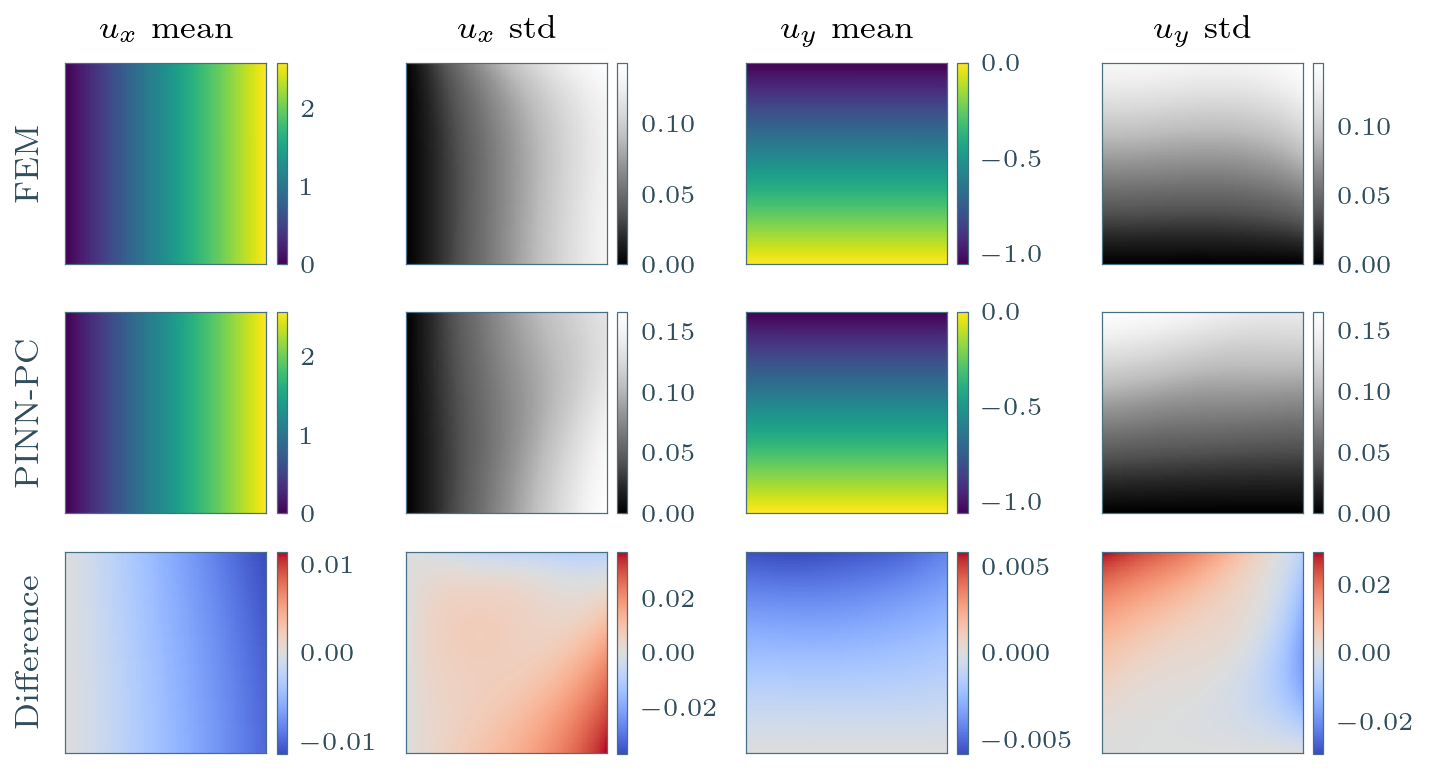

Relative L2 error in ux mean: 7.0994e-01
Relative L2 error in uy mean: 7.1301e-01
Relative L2 error in ux std: 7.2398e-01
Relative L2 error in uy std: 7.5405e-01


In [69]:
# fig_pc, axs = plt.subplots(2, 2, figsize=(0.5 * page_width, 0.45 * page_width), dpi=300, constrained_layout=True)
# fields = [ux_pred_mean, uy_pred_mean, ux_pred_std, uy_pred_std]
# titles = [r"$u_x$ mean", r"$u_y$ mean", r"$u_x$ std", r"$u_y$ std"]
# book_config.set_as_current()
# for ax, field, title in zip(axs.flat, fields, titles):
#     cmap = "viridis" if "mean" in title else "Grays"
#     im = ax.pcolormesh(Xe, Ye, field, shading="auto", cmap=cmap)
#     ax.set_title(title)
#     ax.set_aspect("equal")
#     fig_pc.colorbar(im, ax=ax)
#     ax.set_xticks([])
#     ax.set_yticks([])
# # save_figure(fig_pc, "PC_mean_std")

fig_cmp, axs_cmp = plt.subplots(
    3, 4, figsize=(1 * page_width, 3 * 0.18 * page_width), dpi=300, constrained_layout=True
)

pred_fields = [ux_pred_mean, ux_pred_std, uy_pred_mean, uy_pred_std]
ref_fields = [ux_ref_eval, ux_std_ref_eval, uy_ref_eval, uy_std_ref_eval]
names = [r"$u_x$ mean", r"$u_x$ std", r"$u_y$ mean", r"$u_y$ std"]

for j in range(4):
    cmap = "viridis" if "mean" in names[j] else "Grays_r"

    im0 = axs_cmp[0, j].pcolormesh(Xe, Ye, ref_fields[j].T, shading="auto", cmap=cmap)
    axs_cmp[0, j].set_title(names[j])
    axs_cmp[0, j].set_aspect("equal")
    axs_cmp[0, j].set_xticks([])
    axs_cmp[0, j].set_yticks([])
    fig_cmp.colorbar(im0, ax=axs_cmp[0, j])

    im1 = axs_cmp[1, j].pcolormesh(Xe, Ye, pred_fields[j], shading="auto", cmap=cmap)
    axs_cmp[1, j].set_aspect("equal")
    axs_cmp[1, j].set_xticks([])
    axs_cmp[1, j].set_yticks([])
    fig_cmp.colorbar(im1, ax=axs_cmp[1, j])

    diff = pred_fields[j] - ref_fields[j].T
    vmax = np.max(np.abs(diff))
    if vmax == 0:
        vmax = 1e-12  # avoid zero range in normalization
    norm = mpl.colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    im2 = axs_cmp[2, j].pcolormesh(
        Xe, Ye, diff, shading="auto", cmap="coolwarm", norm=norm
    )
    axs_cmp[2, j].set_aspect("equal")
    axs_cmp[2, j].set_xticks([])
    axs_cmp[2, j].set_yticks([])
    fig_cmp.colorbar(im2, ax=axs_cmp[2, j])



# Row titles
axs_cmp[0, 0].set_ylabel("FEM", rotation=90, labelpad=5, fontsize=plt_cfg().title_font_size)
axs_cmp[1, 0].set_ylabel("PINN-PC", rotation=90, labelpad=5, fontsize=plt_cfg().title_font_size)
axs_cmp[2, 0].set_ylabel("Difference", rotation=90, labelpad=5, fontsize=plt_cfg().title_font_size)

plt.show()
save_figure(fig_cmp, "PINN-PC_vs_MonteCarlo", vector_format="pdf")
#Relative L2 errors
rel_l2_ux_mean = np.linalg.norm(ux_pred_mean - ux_ref_eval) / np.linalg.norm(ux_ref_eval)
rel_l2_uy_mean = np.linalg.norm(uy_pred_mean - uy_ref_eval) / np.linalg.norm(uy_ref_eval)
rel_l2_ux_std = np.linalg.norm(ux_pred_std - ux_std_ref_eval) / np.linalg.norm(ux_std_ref_eval)
rel_l2_uy_std = np.linalg.norm(uy_pred_std - uy_std_ref_eval) / np.linalg.norm(uy_std_ref_eval)
print(f"Relative L2 error in ux mean: {rel_l2_ux_mean:.4e}")
print(f"Relative L2 error in uy mean: {rel_l2_uy_mean:.4e}")
print(f"Relative L2 error in ux std: {rel_l2_ux_std:.4e}")
print(f"Relative L2 error in uy std: {rel_l2_uy_std:.4e}")